# 09. Настоящий текст: обучение и сохранение модели

Лекция: [Обучение на «Капитанской дочке»](../../notes/interview-prep/08m-real-text-training.md).

**Цель:** обучить прежнюю архитектуру на настоящем тексте, выбрать веса по validation, сохранить их и загрузить в новый объект для генерации.

Источник — А. С. Пушкин, «Капитанская дочка», главы I–XIV, Викитека. Данные уже скачаны скриптом рядом с ноутбуком. Сайт обозначает оригинальное произведение как общественное достояние; редакторские приложения и примечания не включены. Точные URL, редакция и хеши лежат в data/captains_daughter/source.json.

**Что новое:** корпус, словарь по train, <unk>, выбор лучшего checkpoint и его загрузка. Attention/блок/модель перенесены из 08. Обучение с нуля: старый словарь на 36 символов не подходит.

После твоего запуска ментор воспроизвёл baseline, проверил сдвиг targets, причинность, отсутствие изменения входа на месте, конечность градиентов и совпадение logits после загрузки весов. Исходная архитектура и твои решения сохранены. В конце добавлен отдельный улучшенный запуск D и готовые пояснения к вопросам. Test не использовался. Для графика требуется Matplotlib; при его отсутствии выводится таблица без установки пакетов.

## Настройки и пути

Параметры архитектуры оставляем прежними: D=32, H=4, два блока, T=32. Увеличим бюджет до 1000 обновлений, а не размер модели. Это первый baseline, не обещание связного текста. Время узнаем по твоим логам.

Пример повтора загрузки в терминале, если папки данных ещё нет:

```powershell
python Seminars/transformers/download_captains_daughter.py
```

Это аналог wget + извлечение текста. Обычный wget скачал бы HTML вместе с меню. Скрипт не перезаписывает существующий корпус. Ячейка ниже вызывает его только при отсутствии chapters.json.

In [1]:
import hashlib
import json
import math
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import torch
import unicodedata
from torch import nn
from torch.nn import functional as F

SEED = 42
CONTEXT_LENGTH = 32
BATCH_SIZE = 16
TRAIN_STEPS = 1000
EVAL_INTERVAL = 100
EVAL_BATCHES = 8
LEARNING_RATE = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

candidates = []
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates.extend([base, base / 'Seminars' / 'transformers'])
LESSON_DIR = next((p for p in candidates if (p / 'download_captains_daughter.py').is_file()), None)
if LESSON_DIR is None:
    raise FileNotFoundError('Открой ноутбук внутри проекта deepschool')
DATA_DIR = LESSON_DIR / 'data' / 'captains_daughter'
if not (DATA_DIR / 'chapters.json').exists():
    subprocess.run([sys.executable, str(LESSON_DIR / 'download_captains_daughter.py')], check=True)

print('PyTorch:', torch.__version__, '| device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
print('Данные:', DATA_DIR)


PyTorch: 2.12.1+cu126 | device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
Данные: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\data\captains_daughter


## A. Разделение до нарезки окон

Train — главы I–X, validation — XI–XII, test — XIII–XIV. Доли по числу символов не обязаны быть 80/10/10. Test сейчас не оцениваем и не используем для словаря или выбора настроек.

Для baseline приводим текст к нижнему регистру и NFC. Пробелы, абзацы и пунктуацию сохраняем. Исходные скачанные файлы не меняются. Названия глав в обучающий поток не добавляем, используем их текст.

In [2]:
chapters = json.loads((DATA_DIR / 'chapters.json').read_text(encoding='utf-8'))
source_info = json.loads((DATA_DIR / 'source.json').read_text(encoding='utf-8'))
if len(chapters) != 14:
    raise ValueError('Для этого урока нужны главы I–XIV; посмотри источник')


def normalize_text(text):
    return unicodedata.normalize('NFC', text).lower()


train_text = normalize_text('\n\n'.join(c['text'] for c in chapters[:10]))
val_text = normalize_text('\n\n'.join(c['text'] for c in chapters[10:12]))
# chapters[12:14] зарезервированы под test. Не создаём test batch в этом уроке.

print('Train:', [c['number'] for c in chapters[:10]], '| символов:', len(train_text))
print('Validation:', [c['number'] for c in chapters[10:12]], '| символов:', len(val_text))
print('Test: XIII–XIV, не оцениваем')
print('Начало train:', repr(train_text[:220]))
print('Редакция источника:', source_info['revision_id'])


Train: ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X'] | символов: 130505
Validation: ['XI', 'XII'] | символов: 29122
Test: XIII–XIV, не оцениваем
Начало train: '— был бы гвардии он завтра ж капитан.\n\n— того не надобно; пусть в армии послужит.\n\n— изрядно сказано! пускай его потужит…\n\n. . . . . . . . . . . . . . .\n\nда кто его отец?\n\nотец мой андрей петрович гринев в молодости свое'
Редакция источника: 5678873


### Словарь только по train

В настоящем тексте есть тире, кавычки, цифры и иностранные буквы. Берём все символы train, а для неизвестного символа добавляем специальный ID 0 — <unk>. Вход всё ещё посимвольный: <unk> — служебный токен, не последовательность из пяти символов.

Validation может содержать неизвестные символы. Выведем их долю, не будем пополнять по ним словарь. Поэтому наш loss — ошибка на закодированном тексте, где неизвестные символы заменены одним ID.

In [3]:
tokens = ['<unk>'] + sorted(set(train_text))
stoi = {token: i for i, token in enumerate(tokens)}
vocab_size = len(tokens)


def encode(text):
    return [stoi.get(char, 0) for char in normalize_text(text)]


def decode(ids, vocabulary=None):
    vocabulary = tokens if vocabulary is None else vocabulary
    return ''.join('�' if int(i) == 0 else vocabulary[int(i)] for i in ids)


train_data = torch.tensor(encode(train_text), dtype=torch.long)
val_data = torch.tensor(encode(val_text), dtype=torch.long)
print('Размер словаря:', vocab_size)
print('Доля неизвестных символов validation:', (val_data == 0).float().mean().item())
print('Пример кодирования:', encode('отец мой'))


Размер словаря: 75
Доля неизвестных символов validation: 0.0
Пример кодирования: [52, 56, 43, 60, 2, 50, 52, 47]


### Самостоятельно: одну знакомую строку

Задай targets для окна длины context_length с началом i. Подсказка: смещение вправо на один символ. Остальное get_batch уже знакомо.

In [4]:
def get_batch(data, generator=None):
    if len(data) <= CONTEXT_LENGTH:
        raise ValueError('Недостаточно символов для окна и target')
    starts = torch.randint(len(data) - CONTEXT_LENGTH, (BATCH_SIZE,), generator=generator)
    x = torch.stack([data[i:i + CONTEXT_LENGTH] for i in starts.tolist()])
    y = torch.stack([data[i + 1:i + CONTEXT_LENGTH + 1] for i in starts.tolist()])
    return x.to(DEVICE), y.to(DEVICE)


preview_rng = torch.Generator().manual_seed(123)
xb, yb = get_batch(train_data, preview_rng)
print('Формы:', xb.shape, yb.shape)
print('Вход:', repr(decode(xb[0].tolist())))
print('Target:', repr(decode(yb[0].tolist())))


Формы: torch.Size([16, 32]) torch.Size([16, 32])
Вход: ' начали свистать около наших уше'
Target: 'начали свистать около наших ушей'


### Остановка A

1. Почему сначала делим главы, а уже потом создаём окна?
2. Что произойдёт с символом validation, которого нет в train?

**Мои ответы:**

1. ...
2. ...

Можно прислать только A. Когда окна понятны — переходи к B.

**Разбор ментора (исходные ответы сохранены):**

1. Сначала делим главы, чтобы пересекающиеся окна из одного исходного участка не попали в разные части. Иначе модель могла бы видеть при обучении почти тот же текст, на котором мы её оцениваем. Общие слова и стиль книги всё равно остаются; это не тест на другие жанры.
2. Неизвестный символ получает ID 0 — <unk>. Словарь по validation не расширяем. В воспроизведённом запуске доля таких символов в validation оказалась 0, но обработка нужна на случай другого текста.


## Готовые компоненты модели

Код не переписываем. Сравнение с прошлым опытом не является чистым экспериментом одной переменной: изменились данные, словарь и бюджет обучения; скрытые размеры и контекст оставили теми же.

In [5]:
class VectorizedCausalAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        if d_model <= 0 or num_heads <= 0 or d_model % num_heads != 0:
            raise ValueError('Нужны положительные D,H и D, кратное H')
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.query_projection = nn.Linear(d_model, d_model, bias=False)
        self.key_projection = nn.Linear(d_model, d_model, bias=False)
        self.value_projection = nn.Linear(d_model, d_model, bias=False)
        self.output_projection = nn.Linear(d_model, d_model, bias=False)

    def project_heads(self, x):
        if x.ndim != 3 or x.shape[-1] != self.d_model or x.shape[1] == 0:
            raise ValueError('Ожидается непустой x формы (B,T,D)')
        batch_size, length, _ = x.shape
        # Готовая реализация из урока 05c: проекция и разделение голов.
        q, k, v = [
            projection(x)
            .reshape(batch_size, length, self.num_heads, self.head_dim)
            .transpose(1, 2)
            for projection in (
                self.query_projection,
                self.key_projection,
                self.value_projection,
            )
        ]

        return q, k, v

    def forward(self, x):
        batch_size, length, _ = x.shape
        q, k, v = self.project_heads(x)
        scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
        positions = torch.arange(x.shape[1], device=x.device)
        blocked = positions[None, :] > positions[:, None]
        masked_scores = scores.masked_fill(blocked, float('-inf'))
        weights = torch.softmax(masked_scores, dim=-1)
        context = weights @ v
        combined = context.transpose(1, 2).reshape(batch_size, length, self.d_model)
        return self.output_projection(combined)

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.norm_1 = nn.LayerNorm(d_model)
        self.attention = VectorizedCausalAttention(d_model, num_heads)
        self.norm_2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        x = x + self.attention(self.norm_1(x))
        x = x + self.mlp(self.norm_2(x))
        return x


In [7]:
class TinyLanguageModel(nn.Module):
    def __init__(self, vocab_size, max_seq_len=16, d_model=8,
                 num_heads=2, d_ff=32, n_layers=1):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff)
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, token_ids):
        if token_ids.ndim != 2:
            raise ValueError('Ожидаются token IDs формы (B,T)')
        length = token_ids.shape[1]
        if not 1 <= length <= self.max_seq_len:
            raise ValueError('Длина должна быть от 1 до max_seq_len')
        positions = torch.arange(length, device=token_ids.device)
        x = self.token_embedding(token_ids) + self.position_embedding(positions)
        for block in self.blocks:
            x = block(x)
        x = self.final_norm(x)
        logits = self.lm_head(x)
        return logits


In [8]:
def train_step(model, optimizer, x, y):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    logits = model(x)
    loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
    if not torch.isfinite(loss).item():
        raise RuntimeError('Loss стал inf/nan: остановись и пришли вывод')
    loss.backward()
    optimizer.step()
    return loss.item()


## Оценка и генерация — служебные функции

Оценка использует одинаковые окна при каждом вызове и не меняет обучающий генератор. Это не полный validation loss по всем символам. Test здесь недоступен функции.

Генерация принимает словарь явно: после загрузки весов обязателен тот же порядок token IDs.

In [9]:
@torch.no_grad()
def estimate_loss(model):
    was_training = model.training
    model.eval()
    results = {}
    try:
        for split, data, seed in [('train', train_data, 1001), ('val', val_data, 1002)]:
            rng = torch.Generator().manual_seed(seed)
            losses = []
            for _ in range(EVAL_BATCHES):
                x, y = get_batch(data, rng)
                logits = model(x)
                loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
                losses.append(loss.item())
            results[split] = sum(losses) / len(losses)
    finally:
        model.train(was_training)
    return results


@torch.no_grad()
def generate(model, prompt, vocabulary, max_new_tokens=200, seed=2026, temperature=1.0):
    if temperature <= 0:
        raise ValueError('temperature должна быть положительной')
    lookup = {token: i for i, token in enumerate(vocabulary)}
    prompt_ids = [lookup.get(c, 0) for c in normalize_text(prompt)]
    if not prompt_ids:
        raise ValueError('Нужен непустой prompt')
    device = next(model.parameters()).device
    ids = torch.tensor([prompt_ids], dtype=torch.long, device=device)
    rng = torch.Generator().manual_seed(seed)
    was_training = model.training
    model.eval()
    try:
        for _ in range(max_new_tokens):
            logits = model(ids[:, -model.max_seq_len:])
            probabilities = torch.softmax(logits[:, -1, :] / temperature, dim=-1)
            next_id = torch.multinomial(probabilities.cpu(), 1, generator=rng).to(device)
            ids = torch.cat([ids, next_id], dim=1)
    finally:
        model.train(was_training)
    return decode(ids[0].tolist(), vocabulary)


## B. Новый запуск и отдельная папка результатов

Эта ячейка создаёт новую модель и новый optimizer. Повтор сбрасывает модель в переменной, но старые файлы остаются: каждому запуску выделяется уникальная папка runs.

Checkpoint здесь предназначен для генерации: сохраняем веса, конфигурацию, словарь и сведения об опыте, но НЕ состояние Adam. Полноценное возобновление обучения из файла — отдельная задача.

In [10]:
torch.manual_seed(SEED)
model_config = dict(vocab_size=vocab_size, max_seq_len=CONTEXT_LENGTH,
                    d_model=32, num_heads=4, d_ff=128, n_layers=2)
model = TinyLanguageModel(**model_config).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
train_rng = torch.Generator().manual_seed(SEED + 1)
steps_done = 0
history = []
best_val = float('inf')
PROMPT = 'отец мой '
run_name = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '-' + uuid4().hex[:8]
RUN_DIR = LESSON_DIR / 'runs' / ('lesson09-' + run_name)
RUN_DIR.mkdir(parents=True, exist_ok=False)
BEST_PATH = RUN_DIR / 'best.pt'
LAST_PATH = RUN_DIR / 'last.pt'

before_metrics = estimate_loss(model)
before_text = generate(model, PROMPT, tokens)
history.append({'step': 0, **before_metrics})
print('Папка запуска:', RUN_DIR)
print('Параметров:', sum(p.numel() for p in model.parameters()))
print('До обучения:', before_metrics)
print(before_text)


Папка запуска: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\runs\lesson09-20260926T180413Z-d7668d7b
Параметров: 31040
До обучения: {'train': 4.505025386810303, 'val': 4.501238167285919}
отец мой ж,…шl—hз?л40tч4:зыnolлщoди“-цс"бс;7“?êuзё.жм«вдбк,�нщбi(экхcс!ч"йэаж
:„",зcч,��l,-aэи«—êд»)êмч�б!чзnал4-(m*m0i?2чиiб«hч,ви2ащeцihщcфсё*кч?«»?й«шh3i0б-4u4зpoп3ь5
бмщёмб»pоmм)ф"!з4я,« 5oж…анпб!*бэ:u37t.


### Что записываем в файл

state_dict — словарь имён параметров и тензоров. Сами Python-классы он не сохраняет. tokens нужны, чтобы ID 10 после загрузки означал тот же символ.

best.pt обновляется только при улучшении выбранного validation loss. last.pt содержит последний завершённый запуск цикла. Перезаписываются только эти файлы внутри новой уникальной папки этого опыта, не старые запуски.

In [11]:
def save_checkpoint(path, model, metrics):
    checkpoint = {
        'format_version': 1,
        'model_state': {name: value.detach().cpu().clone() for name, value in model.state_dict().items()},
        'model_config': dict(model_config),
        'tokens': list(tokens),
        'step': steps_done,
        'metrics': dict(metrics),
        'history': list(history),
        'preprocessing': 'NFC + lowercase; paragraphs retained; chapter titles excluded; train vocabulary + UNK=0',
        'split': {'train': 'I-X', 'validation': 'XI-XII', 'test': 'XIII-XIV, not evaluated'},
        'source': source_info,
        'chapters_sha256': hashlib.sha256((DATA_DIR / 'chapters.json').read_bytes()).hexdigest(),
        'run_settings': {'seed': SEED, 'learning_rate': LEARNING_RATE,
                         'batch_size': BATCH_SIZE, 'eval_batches': EVAL_BATCHES},
        'torch_version': str(torch.__version__),
    }
    torch.save(checkpoint, path)


# Фиксируем исходное состояние как кандидата; обученные веса должны его улучшить.
best_val = before_metrics['val']
save_checkpoint(BEST_PATH, model, before_metrics)


### Обучить 1000 шагов

Заполнять backward/step снова не надо: перенесены из твоего train_step. После каждого оценочного интервала сохраняем лучшую по validation модель. Test не используется.

Повтор только этой ячейки продолжает текущие веса и Adam ещё на TRAIN_STEPS шагов. Не повторяй ячейку создания модели, если хочешь продолжить. Для первого знакомства достаточно одного запуска и разбора результата.

In [12]:
started = time.perf_counter()
for local_step in range(1, TRAIN_STEPS + 1):
    xb, yb = get_batch(train_data, train_rng)
    step_loss = train_step(model, optimizer, xb, yb)
    steps_done += 1
    if local_step == 1 or steps_done % EVAL_INTERVAL == 0 or local_step == TRAIN_STEPS:
        metrics = estimate_loss(model)
        if not all(math.isfinite(v) for v in metrics.values()):
            raise RuntimeError('Оценочный loss стал inf/nan; остановись и пришли вывод')
        history.append({'step': steps_done, **metrics})
        improved = metrics['val'] < best_val
        if improved:
            best_val = metrics['val']
            save_checkpoint(BEST_PATH, model, metrics)
        print(f'step={steps_done:5d} | train={metrics["train"]:.3f} | '
              f'val={metrics["val"]:.3f} | best={best_val:.3f} | '
              f'elapsed={time.perf_counter() - started:.1f}s', flush=True)

save_checkpoint(LAST_PATH, model, metrics)
(RUN_DIR / 'history.json').write_text(json.dumps(history, indent=2) + '\n', encoding='utf-8')
print('Последние веса:', LAST_PATH)
print('Лучшие веса:', BEST_PATH)


step=    1 | train=4.471 | val=4.468 | best=4.468 | elapsed=0.1s


step=  100 | train=2.979 | val=2.976 | best=2.976 | elapsed=0.5s


step=  200 | train=2.741 | val=2.737 | best=2.737 | elapsed=0.9s


step=  300 | train=2.658 | val=2.653 | best=2.653 | elapsed=1.4s


step=  400 | train=2.621 | val=2.620 | best=2.620 | elapsed=1.8s


...

step=  700 | train=2.569 | val=2.569 | best=2.569 | elapsed=3.0s


step=  800 | train=2.546 | val=2.546 | best=2.546 | elapsed=3.5s


step=  900 | train=2.537 | val=2.539 | best=2.539 | elapsed=3.9s


step= 1000 | train=2.519 | val=2.519 | best=2.519 | elapsed=4.3s


Последние веса: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\runs\lesson09-20260926T180413Z-d7668d7b\last.pt
Лучшие веса: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\runs\lesson09-20260926T180413Z-d7668d7b\best.pt


## C. Загрузить лучшую модель в новый объект

Загружай только свои доверенные файлы. weights_only=True ограничивает десериализацию; это не повод скачивать произвольные checkpoint из неизвестных источников.

Два TODO: создать модель по сохранённой конфигурации и загрузить state_dict. Подсказки: TinyLanguageModel(**checkpoint['model_config']) и restored_model.load_state_dict(...).

После Restart Kernel для генерации не надо обучать снова: выполни импорты, normalize_text/decode, определения классов и generate; затем укажи полный путь BEST_PATH к сохранённому файлу и выполни загрузку.

In [13]:
# После перезапуска kernel задай путь к своему файлу вместо использования старой переменной:
# BEST_PATH = Path(r'C:\...\runs\lesson09-...\best.pt')
checkpoint = torch.load(BEST_PATH, map_location='cpu', weights_only=True)

restored_model = TinyLanguageModel(**checkpoint['model_config'])
restored_model.load_state_dict(checkpoint['model_state'])

restored_model = restored_model.to(DEVICE)
restored_model.eval()
restored_tokens = checkpoint['tokens']
print('Шаг выбранной модели:', checkpoint['step'])
print('Её сохранённые метрики:', checkpoint['metrics'])
print(generate(restored_model, 'отец мой ', restored_tokens))


Шаг выбранной модели: 1000
Её сохранённые метрики: {'train': 2.518663763999939, 'val': 2.519202083349228}


отец мой м,… я, залын. имо оту содеря су ст де го ожтя ден, нобо экомы чатостоким, иныль ой си сканавичицача али онат сточипи аруви пойе воразнокованей и е, блоруздиль босво мной погогозня, вдажманико седалил.


### Итог урока

1. Запиши train/validation loss до обучения и у выбранной лучшей модели. Не сравнивай абсолютный loss с уроком 08 как чистый рост/падение качества: корпус и словарь другие.
2. На каком шаге сохранена лучшая модель? Обязательно ли это последний шаг?
3. Что было бы, если загрузить веса, но поменять порядок символов в tokens?
4. Почему сохранённого здесь checkpoint недостаточно для точного продолжения Adam с прежнего места?

**Мои ответы:**

1. ...
2. ...
3. ...
4. ...

Сохрани outputs и пришли результат. Не выкладывай best.pt/last.pt в Git: runs исключён локальным .gitignore. Test не запускаем в процессе подбора. После фиксации настроек выделим отдельную финальную оценку. Baseline воспроизведён ментором; обновлённый вариант D ниже проверяется отдельно.

**Разбор ментора (исходные ответы сохранены):**

1. В твоём baseline train loss: 4.50503 → 2.51866, validation: 4.50124 → 2.51920. Ошибка уменьшилась, но качество генерации пока низкое. Потеря усредняется по истинным контекстам; при генерации модель использует собственные ошибочные символы, поэтому ошибки могут накапливаться.
2. В этом запуске best.pt — шаг 1000. Это не правило: если позже validation ухудшается, best.pt остаётся от более раннего шага.
3. Веса привязаны к ID. Если ID 10 раньше означал «а», а после загрузки стал означать «б», будут неверно трактоваться и входные embeddings, и выходные logits. Даже совпадение размеров тензоров не защитит от такой ошибки.
4. Adam хранит накопленные оценки первого и второго моментов градиентов и счётчики шагов. Здесь они не сохранены. Для точного продолжения нужны также состояния случайности, а при наличии — scheduler/scaler. Веса+словарь+конфигурация достаточны для генерации, не для точного возобновления прежнего процесса оптимизации.

Недостаточный результат baseline — не ошибка заполненных тобой строк. Модель всего на 31 040 параметров, контекст 32 символа, обучение 1000 шагов: это технический первый запуск, а не достаточный бюджет для связной прозы.


## D. Улучшенный запуск — без переписывания архитектуры

Не нужно решать ещё один большой набор заданий. Это готовый опыт для совместного разбора. Исходные A–C оставлены выше.

Ментор сначала продлил маленькую модель до 10 000 шагов: validation на тех же окнах снизился с 2.519 до 1.987, но текст оставался слабым. Затем проверил конфигурацию ниже. Она меняет несколько факторов сразу, поэтому это практический выбор профиля, не доказательство вклада каждого фактора.

| Настройка | Baseline | Улучшенный профиль |
|---|---:|---:|
| d_model | 32 | 128 |
| Контекст, символов | 32 | 128 |
| d_ff | 128 | 512 |
| Блоки / головы | 2 / 4 | 2 / 4 |
| Шаги | 1000 | 6000 |
| Learning rate | 0.001 | 0.0003 |

Получается 431 360 параметров вместо 31 040. Корпус всё ещё мал, связность рассказа не гарантируется. Новый запуск — с нуля, в отдельной папке; исходные файлы весов не перезаписываем. На проверенном RTX 4070 Ti SUPER эксперимент был коротким, но на другом устройстве скорость может отличаться.

In [14]:
# Сохраняем сведения о baseline до замены переменных новым экспериментом.
baseline_summary = {'metrics': dict(checkpoint['metrics']),
                    'step': checkpoint['step'], 'path': str(BEST_PATH)}

CONTEXT_LENGTH = 128
TRAIN_STEPS = 6000
EVAL_INTERVAL = 500
LEARNING_RATE = 3e-4

torch.manual_seed(SEED)
model_config = dict(vocab_size=vocab_size, max_seq_len=CONTEXT_LENGTH,
                    d_model=128, num_heads=4, d_ff=512, n_layers=2)
model = TinyLanguageModel(**model_config).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
train_rng = torch.Generator().manual_seed(SEED + 1)
steps_done = 0
history = []
run_name = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '-' + uuid4().hex[:8]
RUN_DIR = LESSON_DIR / 'runs' / ('lesson09-improved-' + run_name)
RUN_DIR.mkdir(parents=True, exist_ok=False)
BEST_PATH = RUN_DIR / 'best.pt'
LAST_PATH = RUN_DIR / 'last.pt'
before_metrics = estimate_loss(model)
history.append({'step': 0, **before_metrics})
best_val = before_metrics['val']
save_checkpoint(BEST_PATH, model, before_metrics)
print('Новая папка:', RUN_DIR)
print('Параметров:', sum(p.numel() for p in model.parameters()))
print('До обучения:', before_metrics)


Новая папка: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\runs\lesson09-improved-20260926T180418Z-002b7f39
Параметров: 431360
До обучения: {'train': 4.430140435695648, 'val': 4.444169044494629}


In [15]:
started = time.perf_counter()
for local_step in range(1, TRAIN_STEPS + 1):
    xb, yb = get_batch(train_data, train_rng)
    step_loss = train_step(model, optimizer, xb, yb)
    steps_done += 1
    if local_step == 1 or steps_done % EVAL_INTERVAL == 0 or local_step == TRAIN_STEPS:
        metrics = estimate_loss(model)
        if not all(math.isfinite(v) for v in metrics.values()):
            raise RuntimeError('Оценочный loss стал inf/nan; остановись и пришли вывод')
        history.append({'step': steps_done, **metrics})
        improved = metrics['val'] < best_val
        if improved:
            best_val = metrics['val']
            save_checkpoint(BEST_PATH, model, metrics)
        print(f'step={steps_done:5d} | train={metrics["train"]:.3f} | '
              f'val={metrics["val"]:.3f} | best={best_val:.3f} | '
              f'elapsed={time.perf_counter() - started:.1f}s', flush=True)

save_checkpoint(LAST_PATH, model, metrics)
(RUN_DIR / 'history.json').write_text(json.dumps(history, indent=2) + '\n', encoding='utf-8')
print('Последние веса:', LAST_PATH)
print('Лучшие веса:', BEST_PATH)


step=    1 | train=4.374 | val=4.387 | best=4.387 | elapsed=0.0s


step=  500 | train=2.569 | val=2.544 | best=2.544 | elapsed=2.1s


step= 1000 | train=2.516 | val=2.501 | best=2.501 | elapsed=4.3s


step= 1500 | train=2.424 | val=2.413 | best=2.413 | elapsed=6.5s


step= 2000 | train=2.237 | val=2.239 | best=2.239 | elapsed=8.7s


...

step= 4500 | train=1.735 | val=1.842 | best=1.842 | elapsed=19.1s


step= 5000 | train=1.681 | val=1.812 | best=1.812 | elapsed=21.3s


step= 5500 | train=1.634 | val=1.795 | best=1.795 | elapsed=23.4s


step= 6000 | train=1.586 | val=1.769 | best=1.769 | elapsed=25.5s


Последние веса: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\runs\lesson09-improved-20260926T180418Z-002b7f39\last.pt
Лучшие веса: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\runs\lesson09-improved-20260926T180418Z-002b7f39\best.pt


### Загрузить лучшие веса и сравнить на одинаковых коротких окнах

На длинных окнах модель получает другую задачу и другие начальные позиции. Для более сопоставимого сравнения дополнительно оцениваем обе модели на прежних фиксированных окнах длины 32. Профиль выбирался по validation длины 128. Это всё ещё оценки на одном наборе данных и одном seed, не статистическое доказательство.

Словарь и test не меняем.

In [16]:
improved_checkpoint = torch.load(BEST_PATH, map_location='cpu', weights_only=True)
improved_model = TinyLanguageModel(**improved_checkpoint['model_config']).to(DEVICE)
improved_model.load_state_dict(improved_checkpoint['model_state'])
improved_model.eval()
improved_tokens = improved_checkpoint['tokens']

previous_context = CONTEXT_LENGTH
try:
    CONTEXT_LENGTH = 32
    common_window_metrics = estimate_loss(improved_model)
finally:
    CONTEXT_LENGTH = previous_context

print('Baseline, T=32:', baseline_summary)
print('Улучшенная модель, те же окна T=32:', common_window_metrics)
print('Улучшенная модель, T=128:', improved_checkpoint['metrics'])
print('Лучший шаг:', improved_checkpoint['step'])
print('Файл для дальнейшей генерации:', BEST_PATH)


Baseline, T=32: {'metrics': {'train': 2.518663763999939, 'val': 2.519202083349228}, 'step': 1000, 'path': 'C:\\Users\\Admin\\PycharmProjects\\deepschool\\Seminars\\transformers\\runs\\lesson09-20260926T180413Z-d7668d7b\\best.pt'}
Улучшенная модель, те же окна T=32: {'train': 1.6587663292884827, 'val': 1.7613708972930908}
Улучшенная модель, T=128: {'train': 1.5863161087036133, 'val': 1.7687982022762299}
Лучший шаг: 6000
Файл для дальнейшей генерации: C:\Users\Admin\PycharmProjects\deepschool\Seminars\transformers\runs\lesson09-improved-20260926T180418Z-002b7f39\best.pt


### График обучения улучшенного профиля

Train и validation оценены на фиксированных окнах длины 128. Средние loss даны в натуральных логарифмах на символ; меньше — лучше. Это выборочные оценки без доверительных интервалов. Расхождение кривых полезнее, чем один удачный пример текста.

На этом компьютере совместный импорт PyTorch и Matplotlib в один процесс вызвал конфликт OpenMP. График поэтому строится отдельным коротким процессом без PyTorch. Опасный обход KMP_DUPLICATE_LIB_OK не используется. Это служебная особенность окружения, не ошибка нейросети.


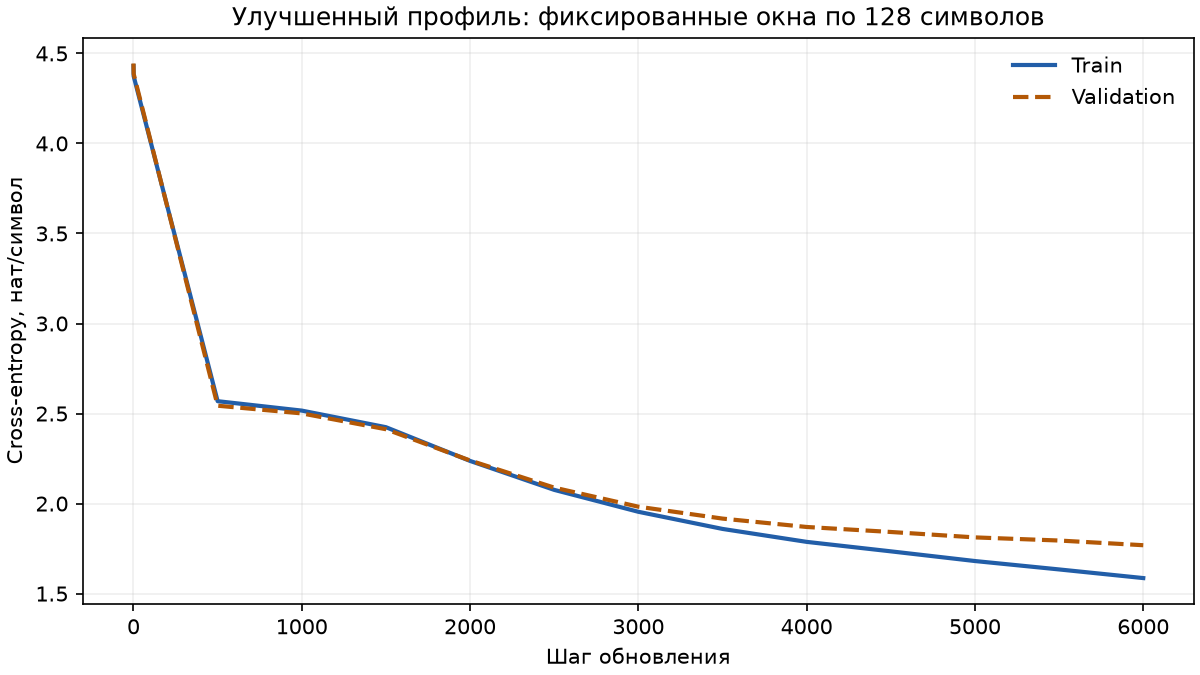

In [17]:
# Рисуем в отдельном процессе: не смешиваем OpenMP-библиотеки PyTorch и Matplotlib.
curve_path = RUN_DIR / 'learning-curve.png'
plot_result = subprocess.run(
    [sys.executable, str(LESSON_DIR / 'plot_learning_curve.py'), '--output', str(curve_path)],
    input=json.dumps(history), text=True, capture_output=True,
)
if plot_result.returncode == 0:
    from IPython.display import Image, display
    display(Image(filename=str(curve_path)))
else:
    print('График не построен; обучение и checkpoint не затронуты.')
    print(plot_result.stderr[-1500:])
    for row in history:
        print(row)


### Генерация при двух температурах — не новое обучение

temperature=1 — обычная выборка из модели. При 0.8 выбор чаще склоняется к вероятным символам. Это может уменьшить случайные ошибки, но не добавляет модели знания и может усилить повторы. Метрики выше считались по исходным logits, без температуры. Prompt и seed одинаковые, тексты не выбираются из десятков попыток.

In [18]:
for temperature in [1.0, 0.8]:
    print(f'\nTEMPERATURE = {temperature}')
    print(generate(improved_model, 'отец мой ', improved_tokens,
                   max_new_tokens=400, seed=2026, temperature=temperature))



TEMPERATURE = 1.0


отец мой думался, легко мог пулалась. суба; другого тягое вам богу хладеят. докая, иван иговничана встерпать легко изволичи, что, иваное воротило комендант, благослил надевось на погрятива, которанию комендант, который порас, нерисьмо вманна безбога. швабрин и про андре, оборый меня корот гнизобный превородойно о баравилсем пристарел. "василиса иваных и прики. я, ислушался не изможный импиться одельные ков

TEMPERATURE = 0.8


отец мой пришу, заленных задеть, образский марья ивановна каков горомы человек: «его, — сказал она, — что что, это всё мой писанили подале мне око вам за ее благосли добнову мне. погадала его. «маник! седарь, — казали казала мне, — молчта он стараная шписание извола его получал меня корот голотовы, превосовна смотращавились приставился в за казаки постину и и важду и простоный стоянностию трачном и делатьн


### Что делать теперь

Не увеличивай число шагов вслепую. Посмотри график и два текста. Наша цель на этом этапе — больше узнаваемых слов и оборотов, а не уже готовый рассказ с сюжетом. Даже улучшенная модель может генерировать бессмыслицу: здесь одна книга, посимвольные токены, короткий контекст и обучение с нуля.

Для повторной генерации запускай только последнюю ячейку, а не создание model. Точные ответы на вопросы уже добавлены выше; обсудим их без нового экзамена. Test-главы XIII–XIV всё ещё не оценивались.


## Итог проверки ментором

Обновлённый notebook выполнен целиком в свежем kernel окружения deepschool; исключений в итоговом запуске нет. Формат проверен nbformat. Текстовые outputs прочитаны, сохранённый график просмотрен как PNG (полная страница ноутбука визуально не проверялась). Исходный вариант пользователя сохранён в runs/user-before-mentor09.ipynb; его файлы checkpoint не изменялись.

Отдельные проверки baseline: сдвиг targets, causal mask, неизменность входа, конечные градиенты всех параметров, совпадение logits после загрузки — прошли. Улучшенный профиль воспроизвёл train=1.58632 и validation=1.76880 на окнах 128; на одинаковых с baseline окнах 32 validation=1.76137 вместо 2.51920. Качество генерации всё ещё ограничено: реальные слова и имена появляются чаще, связный рассказ не получен. Test не использовался.

Лучший улучшенный checkpoint этого запуска: runs/lesson09-improved-20260926T180418Z-002b7f39/best.pt. Для чтения результатов повторное обучение не требуется. Разрешение на запуск распространялось на этот notebook. Коммит не выполнялся.
